## 5.5 양자 랜덤 접근 메모리 (QRAM) with Qiskit

In [1]:
# Qiskit에서 필요한 라이브러리 불러오기
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 큐비트 3개 + 고전 비트 3개로 양자 회로 초기화
qr = QuantumRegister(3, 'q')
cr = ClassicalRegister(3, 'c')
qc = QuantumCircuit(qr, cr)

In [3]:
# QRAM: 데이터를 양자 상태에 인코딩
# 예: |001> 이 값 1, |010> 이 값 2 등에 대응하도록 인코딩
qc.h(qr[0])           # 하다마드로 중첩 생성
qc.cx(qr[0], qr[1])   # CNOT으로 큐비트 얽기
qc.cx(qr[1], qr[2])   # CNOT으로 추가로 얽기

In [4]:
# 회전을 적용해 정보를 인코딩
qc.ry(0.5, qr[1])
qc.rz(0.8, qr[2])

In [5]:
# 양자 상태를 측정해 데이터 검색
qc.measure(qr, cr)

In [6]:
# 회로에 SaveStatevector 명령 추가
qc.save_statevector()

Quantum Circuit for QRAM:


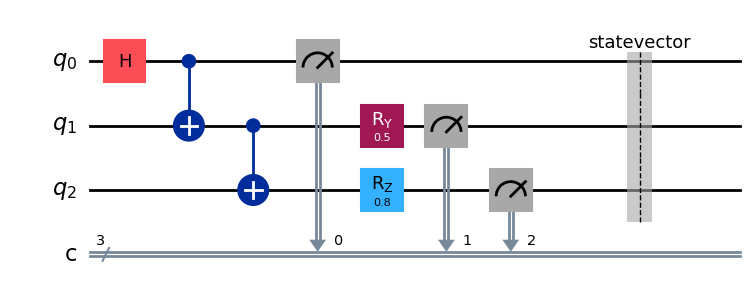

In [7]:
# 양자 회로 그리기
print("Quantum Circuit for QRAM:")
qc.draw('mpl')
plt.show()

In [8]:
# AerSimulator로 상태벡터 얻기
simulator = AerSimulator()

In [9]:
# 시뮬레이터용으로 회로 트랜스파일
compiled_circuit = transpile(qc, simulator)

In [10]:
# 회로 실행
job = simulator.run(compiled_circuit, shots=1024)

In [11]:
# 카운트(측정 결과) 얻기
counts = job.result().get_counts()

Measurement results:


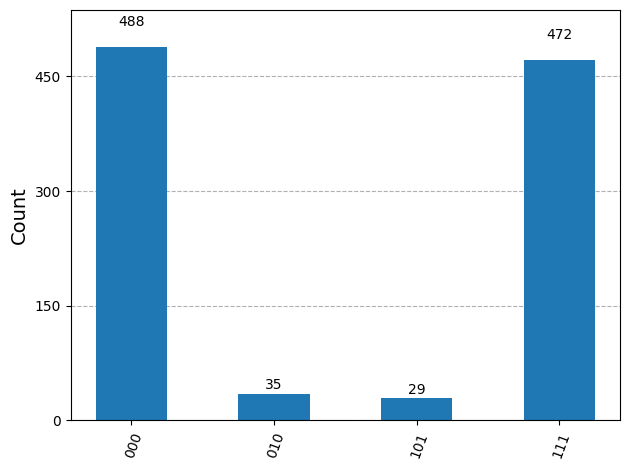

In [12]:
# 결과 히스토그램 그리기
print("Measurement results:")
plot_histogram(counts)
plt.show()

In [13]:
# 최종 양자 상태의 상태벡터 얻기
statevector = job.result().get_statevector()

Bloch Sphere representation of the final quantum state:


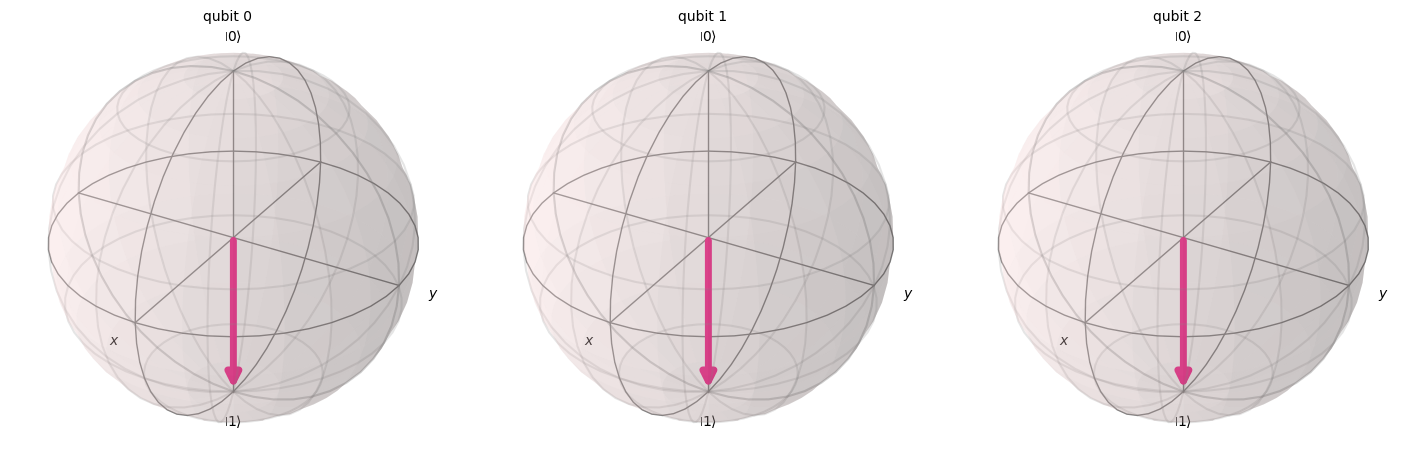

In [14]:
# 양자 상태의 블로흐 구 표현 그리기
print("Bloch Sphere representation of the final quantum state:")
plot_bloch_multivector(statevector)
plt.show()